# APPLES 3

### IMPORT

In [1]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

### DATA

In [2]:
months = [
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512"
]

my_files = [
    [f"../data/processed/eurnok_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eurnok_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_bid_{m}.parquet" for m in months],
]

### SPREAD

In [3]:
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(10, 14))
df = builder.build(my_files)

print(df.head(3))
print("\nColumns:", list(df.columns))
print(f"Median half-spread (bps) — A: {df['HalfSpread_A_bps'].median():.2f} | "
      f"B: {df['HalfSpread_B_bps'].median():.2f}")

built 12868 rows
                                    Asset_A     Bid_A     Ask_A    Asset_B  \
timestamp                                                                    
2025-01-02 10:08:24.604000+00:00  11.742865  11.74017  11.74556  11.434930   
2025-01-02 10:13:34.547000+00:00  11.746710  11.74399  11.74943  11.436620   
2025-01-02 10:17:20.398000+00:00  11.748715  11.74598  11.75145  11.443115   

                                     Bid_B     Ask_B     Log_A     Log_B  \
timestamp                                                                  
2025-01-02 10:08:24.604000+00:00  11.43251  11.43735  2.463246  2.436673   
2025-01-02 10:13:34.547000+00:00  11.43422  11.43902  2.463573  2.436820   
2025-01-02 10:17:20.398000+00:00  11.44042  11.44581  2.463744  2.437388   

                                  Return_A  Return_B  HalfSpread_A_bps  \
timestamp                                                                
2025-01-02 10:08:24.604000+00:00  0.000109  0.000074          2

### SCREENER

In [4]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report()

     COINTEGRATION SCREENER REPORT      
P-Value:    0.27915 -> fail (not cointegrated)
Half-Life:  628.92 Bars
----------------------------------------
Verdict: DO NOT TRADE. Spread is a random walk.



In [5]:
# Target 5-10x the half-life, clipped to [500, 5000] bars
target_coint_window = int(np.clip(8 * hl if np.isfinite(hl) else 2000, 500, 5000))
print(f"Using coint_window = {target_coint_window} bars (half-life was {hl:.1f})")

Using coint_window = 5000 bars (half-life was 628.9)


### ENGINE

In [6]:
df['Date'] = df.index.date
unique_days = df['Date'].unique()
train_days = 30
Z_WINDOW = 250

# Size coint_window to fit a typical training fold
bars_per_fold = len(df[df['Date'].isin(unique_days[:train_days])])
COINT_WINDOW = min(2000, int(0.4 * bars_per_fold))
print(f"Bars/fold: {bars_per_fold} | coint_window: {COINT_WINDOW} | z_window: {Z_WINDOW}")

out_of_sample_results, parameter_tracker = [], []

for i in range(train_days, len(unique_days)):
    train_df = df[df['Date'].isin(unique_days[i - train_days : i])].copy()
    test_df  = df[df['Date'] == unique_days[i]].copy()
    if len(train_df) <= COINT_WINDOW + Z_WINDOW + 10 or len(test_df) < 5:
        continue

    engine = ENGINE(train_df)
    engine.fit_cointegration(coint_window=COINT_WINDOW, z_window=Z_WINDOW)
    engine.fit_ar_reversion(lags=1)
    engine.fit_garch_vol(scaling=10000)
    engine.fit_markov_regimes(k_regimes=2)

    out_of_sample_results.append(engine.predict_oos(
        test_df, engine.data, z_window=Z_WINDOW, coint_window=COINT_WINDOW))
    parameter_tracker.append({
        'Date': unique_days[i], 'Beta': engine.beta, 'Alpha': engine.alpha,
        'Safe_Variance': engine.safe_variance, 'Danger_Variance': engine.danger_variance,
        'GARCH_Vol': engine.forecasted_vol, 'AR_Phi': engine.ar_phi})

    if i % 10 == 0:
        print(f"[{unique_days[i]}] Beta: {engine.beta:.4f} | GARCH: {engine.forecasted_vol:.2f} | AR: {engine.ar_phi:.4f}")

assert out_of_sample_results, "No folds ran — lower COINT_WINDOW or train_days."
live_trading_data = pd.concat(out_of_sample_results)
df_params = pd.DataFrame(parameter_tracker).set_index('Date')
print(f"\nOOS rows: {len(live_trading_data)} | Folds: {len(out_of_sample_results)}")

Bars/fold: 1515 | coint_window: 606 | z_window: 250
[ROLLING] Cointegration Fitted over 606-bar window | Last Beta: 0.6348 | Last Alpha: 0.9146 | Valid rows: 661
Markov Fitted (k=2) | Danger Var: 802.58 | Safe Var: 4.85
[2025-02-13] Beta: 0.6348 | GARCH: 4.64 | AR: 0.9811
[ROLLING] Cointegration Fitted over 606-bar window | Last Beta: 0.4826 | Last Alpha: 1.2852 | Valid rows: 679
Markov Fitted (k=2) | Danger Var: 1029.49 | Safe Var: 4.88
[ROLLING] Cointegration Fitted over 606-bar window | Last Beta: 0.3755 | Last Alpha: 1.5452 | Valid rows: 708
Markov Fitted (k=2) | Danger Var: 1043.20 | Safe Var: 4.87
[ROLLING] Cointegration Fitted over 606-bar window | Last Beta: 0.3348 | Last Alpha: 1.6441 | Valid rows: 692
Markov Fitted (k=2) | Danger Var: 1110.25 | Safe Var: 5.08
[ROLLING] Cointegration Fitted over 606-bar window | Last Beta: 0.3245 | Last Alpha: 1.6692 | Valid rows: 706
Markov Fitted (k=2) | Danger Var: 1144.81 | Safe Var: 4.94
[ROLLING] Cointegration Fitted over 606-bar window 

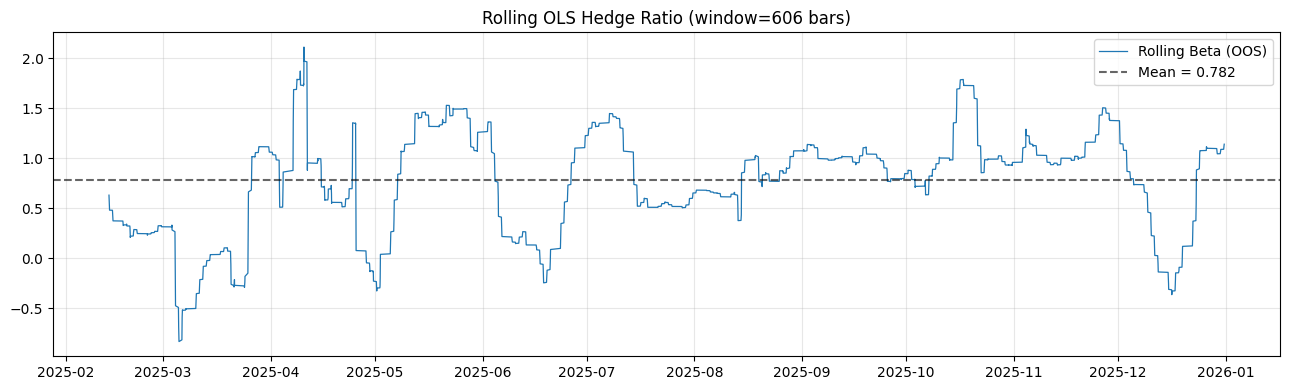

Beta range: [-0.831, 2.113]
Beta std:    0.5359


In [7]:
# Plot rolling beta over the OOS period to see whether the hedge ratio drifts
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(live_trading_data.index, live_trading_data['Beta'],
        color='tab:blue', linewidth=0.9, label='Rolling Beta (OOS)')
ax.axhline(live_trading_data['Beta'].mean(), color='black', linestyle='--',
           alpha=0.6, label=f"Mean = {live_trading_data['Beta'].mean():.3f}")
ax.set_title(f"Rolling OLS Hedge Ratio (window={COINT_WINDOW} bars)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Beta range: [{live_trading_data['Beta'].min():.3f}, "
      f"{live_trading_data['Beta'].max():.3f}]")
print(f"Beta std:    {live_trading_data['Beta'].std():.4f}")

### BACKTESTER

In [8]:
bt = BACKTESTER(live_trading_data)
results_df = bt.run(
    base_z=1.25,
    exit_z=0.0,
    danger_threshold=0.7,          # fixed: was 1.1 which never triggered
    ar_limit=0.995,
    fee_bps=0.5,
    stop_loss_bps=100.0,
    take_profit_bps=25.0,
    max_hold_bars=150,
    slippage_mode='half_spread',   # realistic execution cost
)

### TEARSHEET


           INSTITUTIONAL PERFORMANCE REPORT            
Metric                    | Adaptive     | Static Base 
-------------------------------------------------------
Total Return (Bps)        | -1175.57     | 705.96      
Annual Vol (Bps)          | 433.38       | 597.33      
Sharpe Ratio              | -2.98        | 1.30        
Sortino Ratio             | -2.17        | 1.14        
Max Drawdown (Bps)        | -1281.39     | -750.71     
Calmar Ratio              | 0.92         | 0.94        
Win Rate                  | 46.29%       | 49.43%      
Profit Factor             | 0.87         | 1.07        



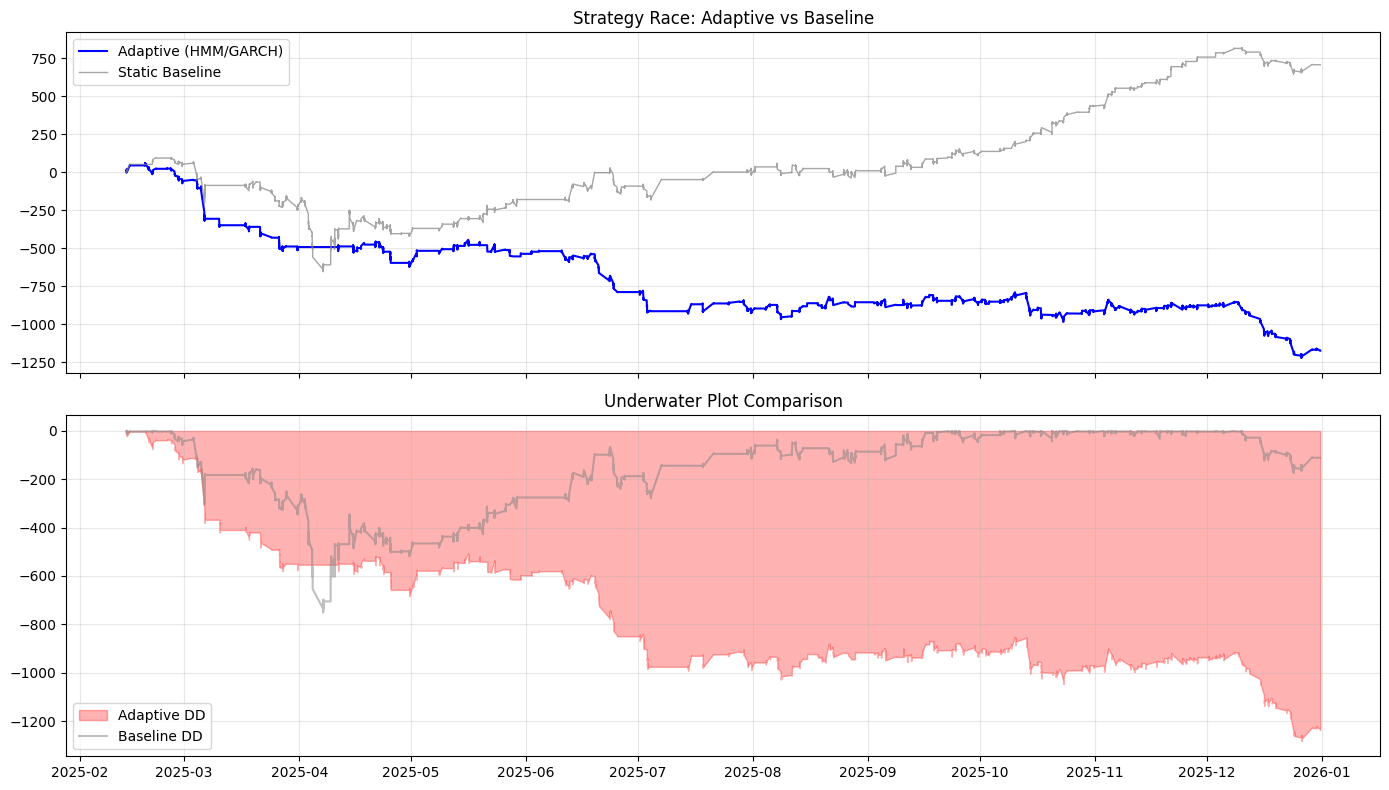

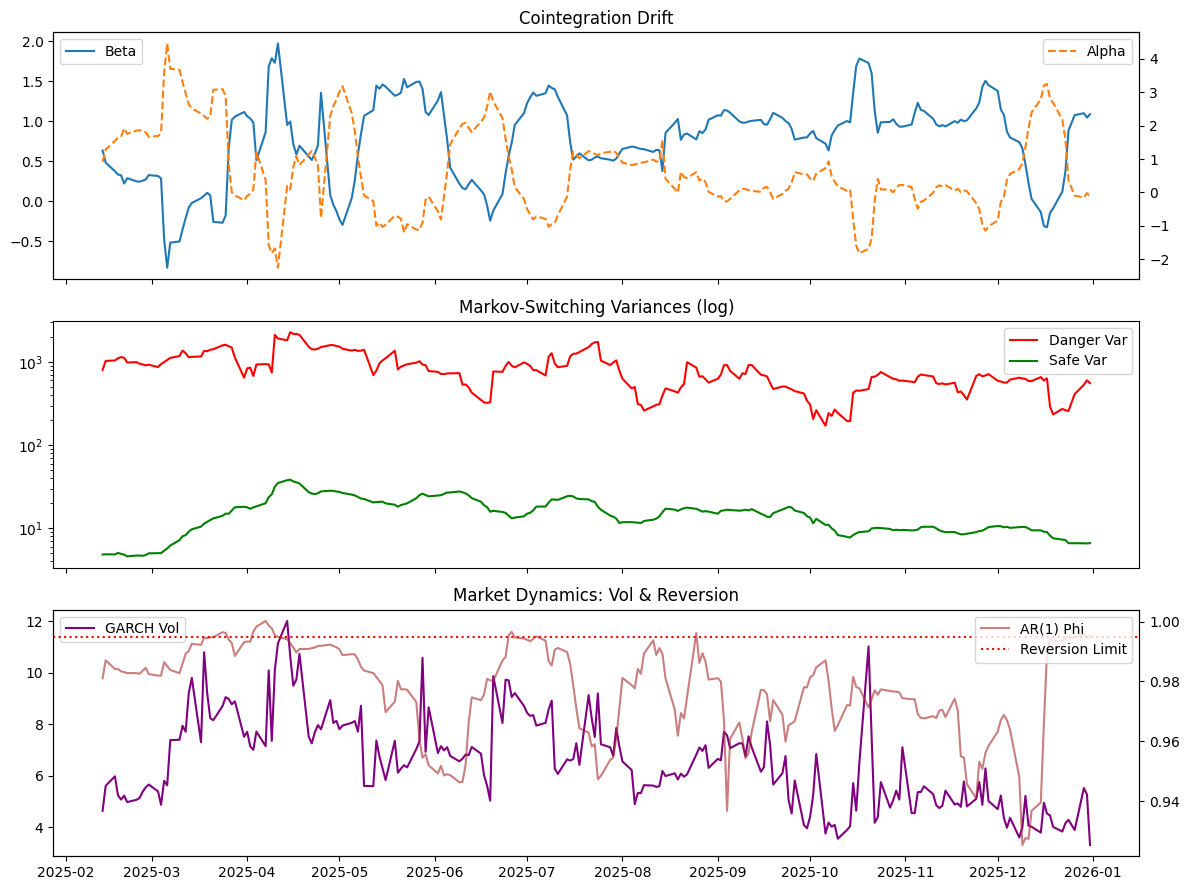

In [9]:
ts = TEARSHEET(results_df, df_params=df_params)
ts.generate_report()
ts.plot_comparative_equity()
ts.plot_engine_parameters()

In [10]:
heat_df = ts.plot_robustness_heatmap(
    engine_data=live_trading_data,
    base_z_grid=np.round(np.arange(0.75, 2.51, 0.25), 2),
    danger_grid=np.round(np.arange(0.3, 0.96, 0.1), 2),
    fixed_params={
        'exit_z': 0.0,
        'ar_limit': 0.995,
        'fee_bps': 0.5,
        'stop_loss_bps': 100.0,
        'take_profit_bps': 25.0,
        'max_hold_bars': 150,
        'slippage_mode': 'half_spread',
    },
    metric='sharpe',
)
print("\nTop 5 (base_z, danger_threshold) by Sharpe:")
print(heat_df.stack().sort_values(ascending=False).head(5))

NameError: name 'BACKTESTER' is not defined

In [ ]:
# Quick A/B: does rolling cointegration materially change the adaptive PnL
# vs the old static full-sample fit? Run one pass with the static method and
# compare Sharpe. This cell is optional; it demonstrates the old approach.

def run_static_pipeline():
    rows = []
    for i in range(train_days, len(unique_days)):
        train_dates = unique_days[i - train_days : i]
        test_date = unique_days[i]
        tr = df[df['Date'].isin(train_dates)].copy()
        te = df[df['Date'] == test_date].copy()
        if len(tr) <= Z_WINDOW + 50:
            continue
        eng = ENGINE(tr)
        eng.fit_cointegration_static(z_window=Z_WINDOW)  # <-- the old behavior
        eng.fit_ar_reversion(lags=1)
        eng.fit_garch_vol(scaling=10000)
        eng.fit_markov_regimes(k_regimes=2)
        oos = eng.predict_oos(
            test_df=te, train_tail_df=eng.data, z_window=Z_WINDOW,
            coint_window=COINT_WINDOW, coint_refit_every=1,
            refit_every=500, garch_window=5000, ar_window=2000,
        )
        rows.append(oos)
    return pd.concat(rows)

# NOTE: predict_oos still uses rolling coint across the boundary; to make this
# a true apples-to-apples against a pure static approach, set coint_window
# very large (effectively expanding) or write a short static-OOS helper.
# For now, treat this as an illustration of the API, not a clean benchmark.